In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, r2_score, mean_squared_error
)

plt.style.use('seaborn-v0_8')
print('All libraries imported successfully!')

All libraries imported successfully!


In [20]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [21]:
print('--- Dataset Info ---')
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

In [22]:
print('--- Statistical Summary ---')
df.describe()

--- Statistical Summary ---


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [23]:
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate: {df["Attrition"].value_counts(normalize=True)["Yes"]*100:.2f}%')

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [24]:
# Check missing values
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else ' No missing values found')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

--- Missing Values ---
 No missing values found

Duplicate rows: 0


In [25]:
# Drop columns with single unique value — useless for analysis
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)
print(f' Dropped constant/ID columns: {cols_to_drop}')
print(f'New shape: {df.shape}')

 Dropped constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)


In [26]:
# Detect outliers using IQR method
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('--- Outlier Count per Column (IQR Method) ---')
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if count > 0:
        outlier_summary[col] = count

print(pd.Series(outlier_summary).sort_values(ascending=False))

--- Outlier Count per Column (IQR Method) ---
TrainingTimesLastYear      238
PerformanceRating          226
MonthlyIncome              114
YearsSinceLastPromotion    107
YearsAtCompany             104
StockOptionLevel            85
TotalWorkingYears           63
NumCompaniesWorked          52
YearsInCurrentRole          21
YearsWithCurrManager        14
dtype: int64


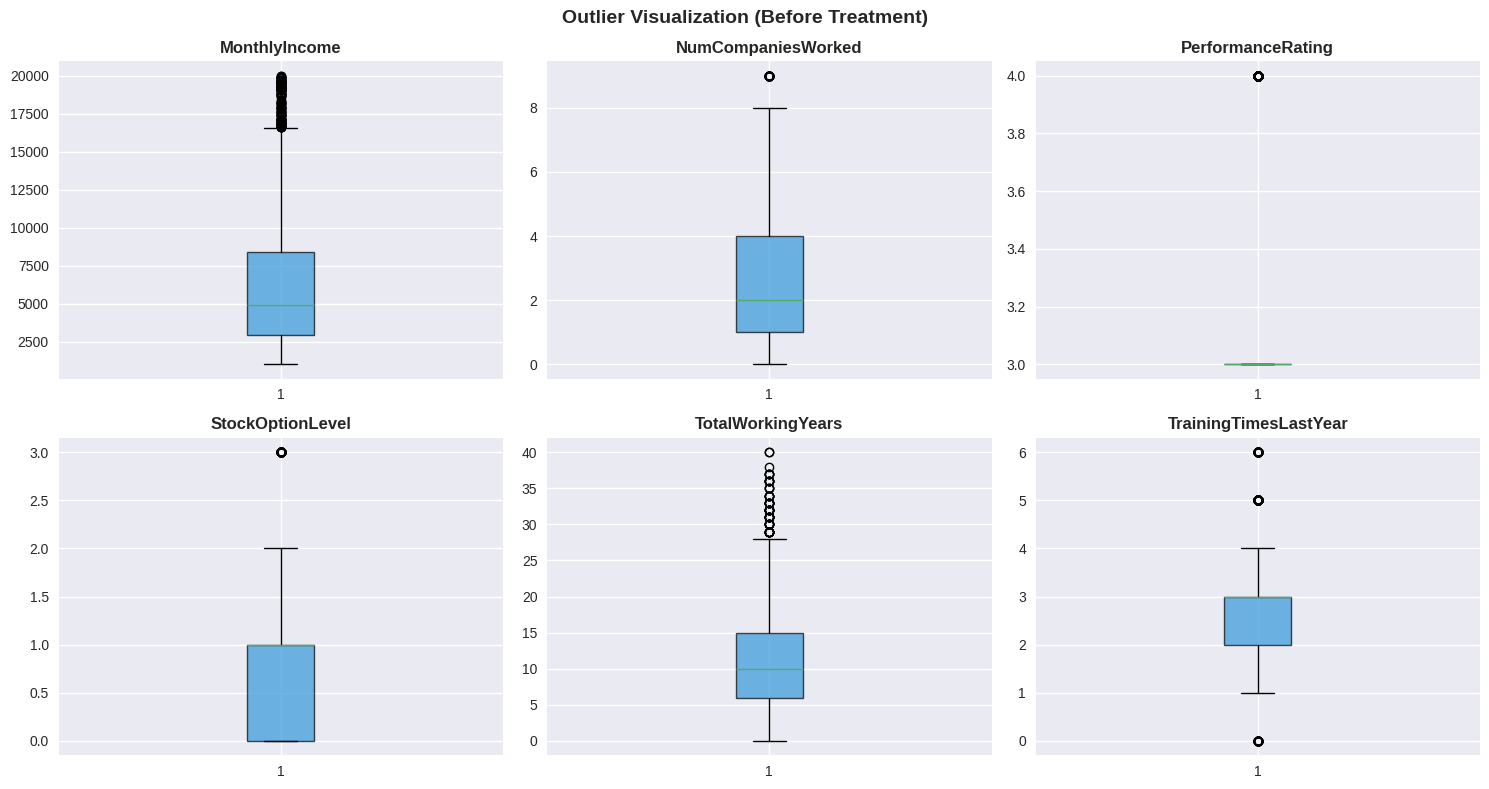

In [27]:
# Visualize top outliers with boxplots
top_outlier_cols = list(outlier_summary.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_outlier_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Outlier Visualization (Before Treatment)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_0_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Treat outliers using IQR Winsorization (capping)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print(' Outliers treated using IQR Winsorization (capping method)')

 Outliers treated using IQR Winsorization (capping method)


In [29]:
# Feature Engineering
df['IncomePerYear']    = df['MonthlyIncome'] * 12
df['TenureRatio']      = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['SatisfactionScore']= (df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction']) / 3
df['IncomeToJobLevel'] = df['MonthlyIncome'] / (df['JobLevel'] + 1)
df['AgeSatisfaction']  = df['Age'] * df['SatisfactionScore']

print(' New engineered features:')
print('  - IncomePerYear, TenureRatio, SatisfactionScore, IncomeToJobLevel, AgeSatisfaction')

 New engineered features:
  - IncomePerYear, TenureRatio, SatisfactionScore, IncomeToJobLevel, AgeSatisfaction


In [30]:
# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Label encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print('All categorical variables encoded')
print(f'Final shape: {df.shape}')

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
All categorical variables encoded
Final shape: (1470, 36)


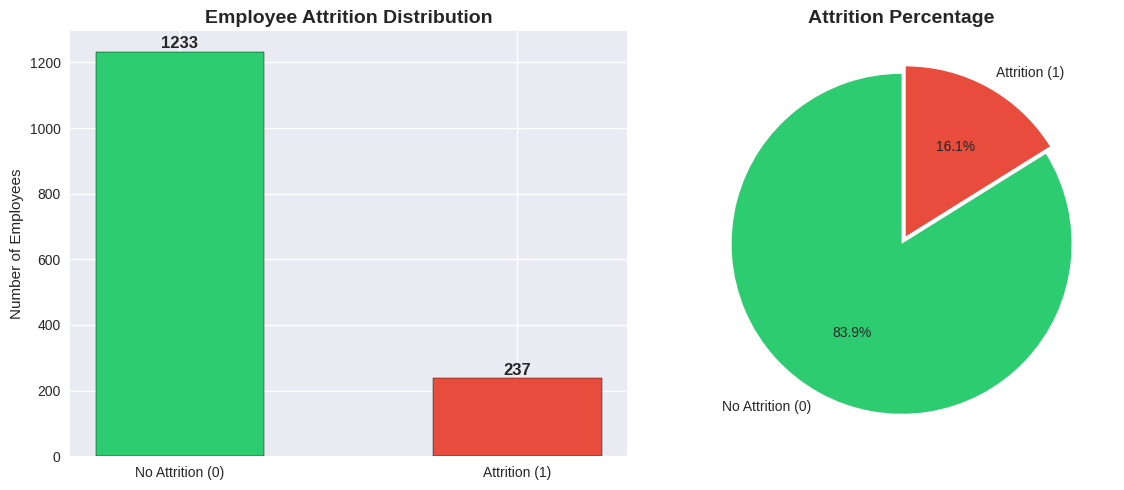

In [31]:
# Plot 1: Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
attrition_counts = df['Attrition'].value_counts()
labels = ['No Attrition (0)', 'Attrition (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, attrition_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(attrition_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Attrition Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_1_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

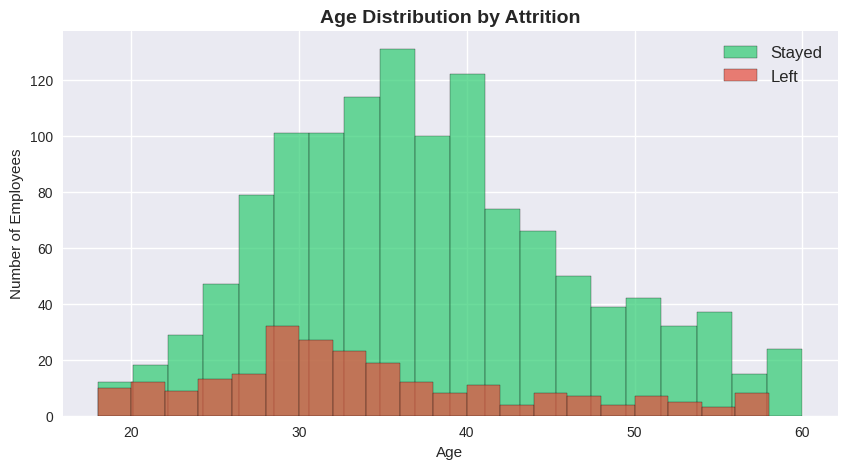

Insight: Younger employees (20-35) show higher attrition rates.


In [32]:
# Plot 2: Age Distribution Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Attrition']==0]['Age'], bins=20, alpha=0.7, label='Stayed', color='#2ecc71', edgecolor='black')
ax.hist(df[df['Attrition']==1]['Age'], bins=20, alpha=0.7, label='Left', color='#e74c3c', edgecolor='black')
ax.set_title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Employees')
ax.legend(fontsize=12)
plt.savefig('plot_2_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Younger employees (20-35) show higher attrition rates.')

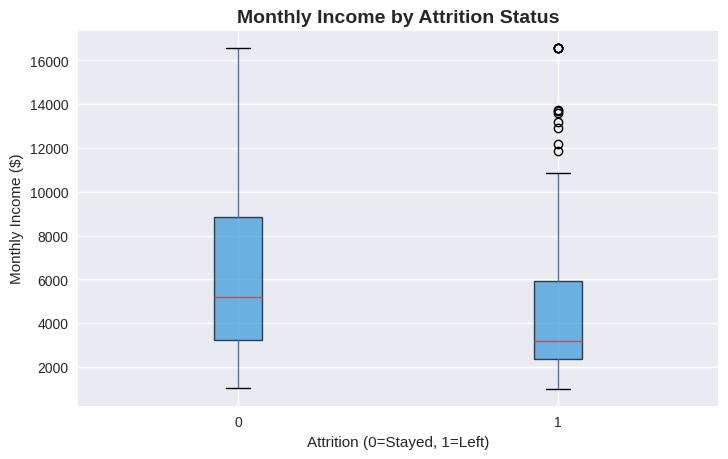

Insight: Employees who left earned significantly less on average.


In [33]:
# Plot 3: Monthly Income Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='MonthlyIncome', by='Attrition', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
ax.set_title('Monthly Income by Attrition Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Attrition (0=Stayed, 1=Left)')
ax.set_ylabel('Monthly Income ($)')
plt.suptitle('')
plt.savefig('plot_3_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Employees who left earned significantly less on average.')

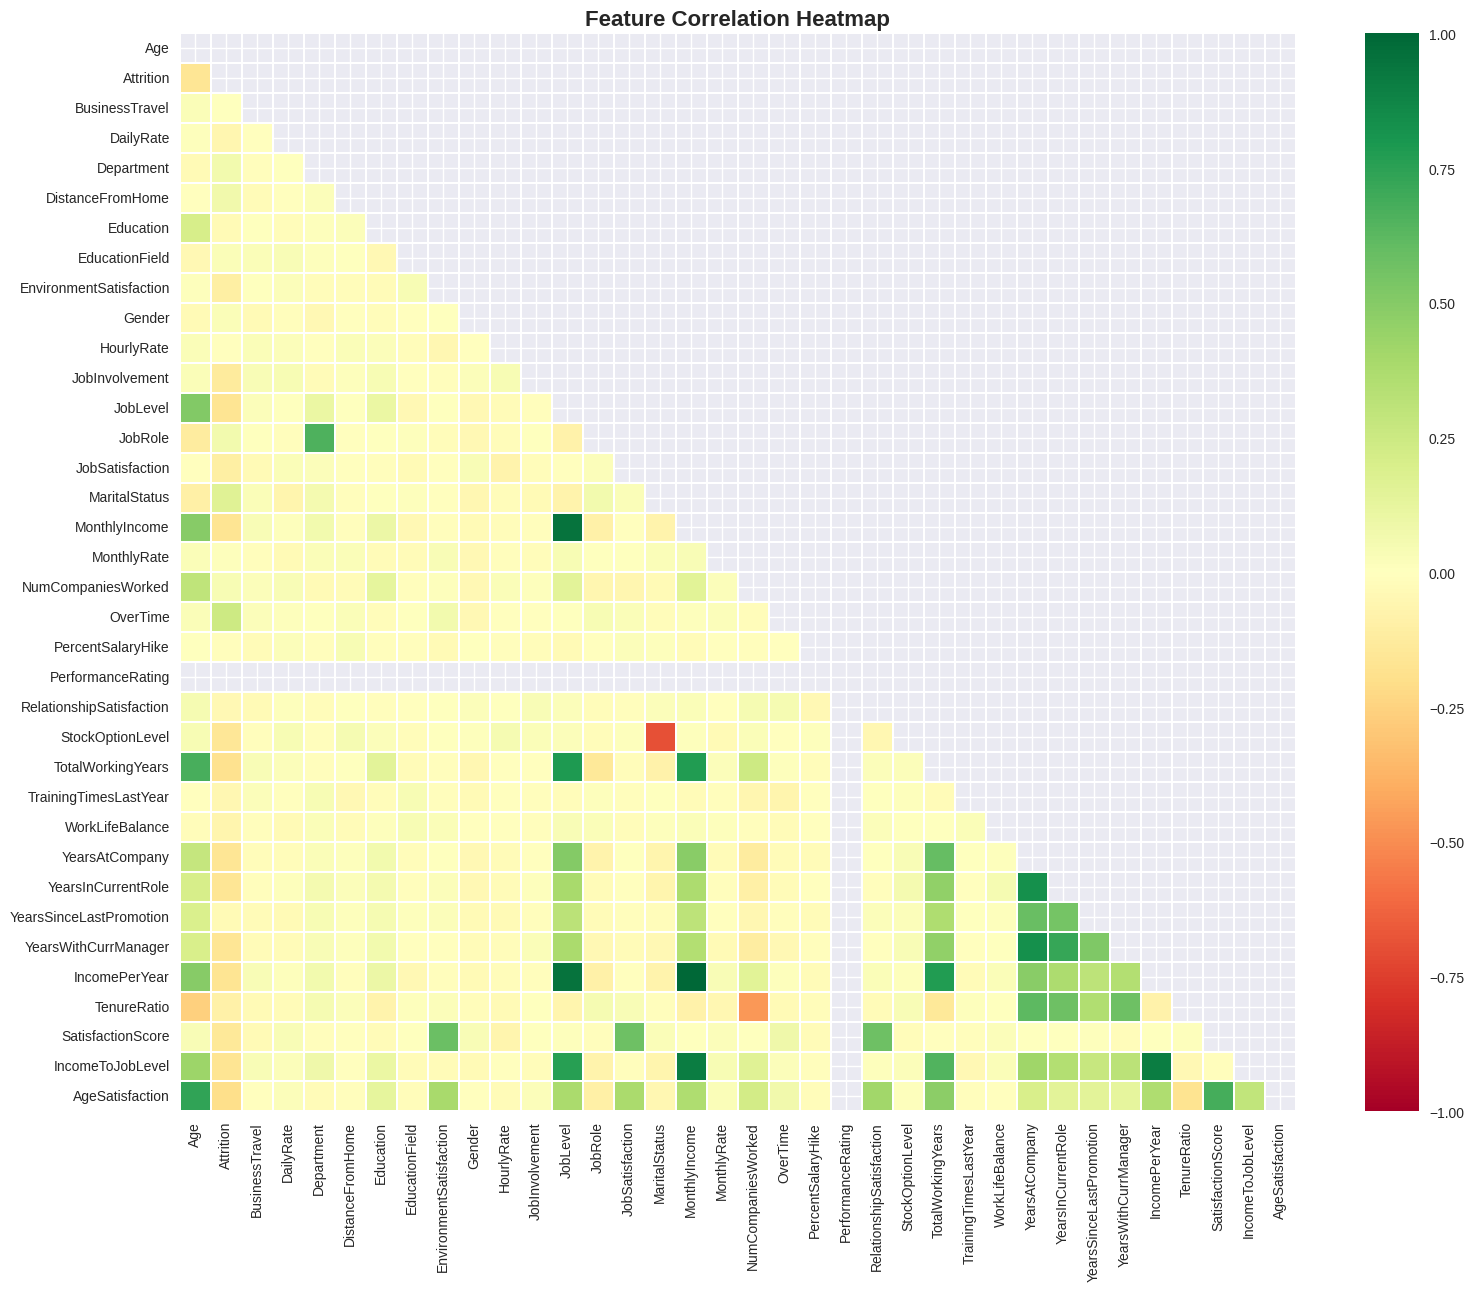

In [34]:
# Plot 4: Correlation Heatmap
fig, ax = plt.subplots(figsize=(18, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig('plot_4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

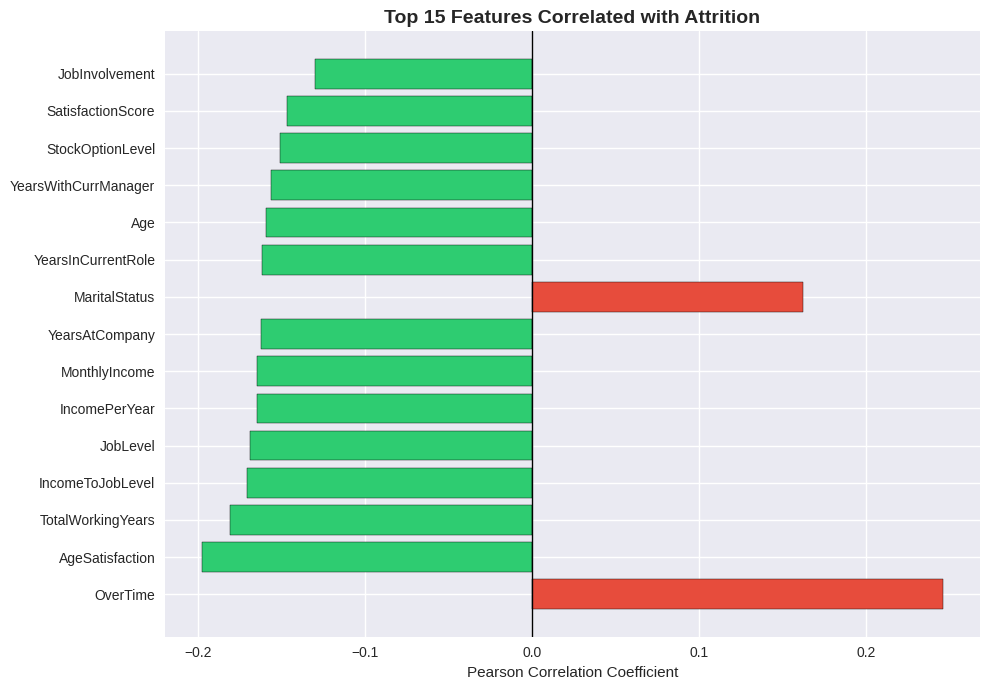

In [35]:
# Plot 5: Top Features Correlated with Attrition
attrition_corr = df.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_c = ['#e74c3c' if x > 0 else '#2ecc71' for x in attrition_corr.values]
bars = ax.barh(attrition_corr.index, attrition_corr.values, color=colors_c, edgecolor='black')
ax.set_title('Top 15 Features Correlated with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('plot_5_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

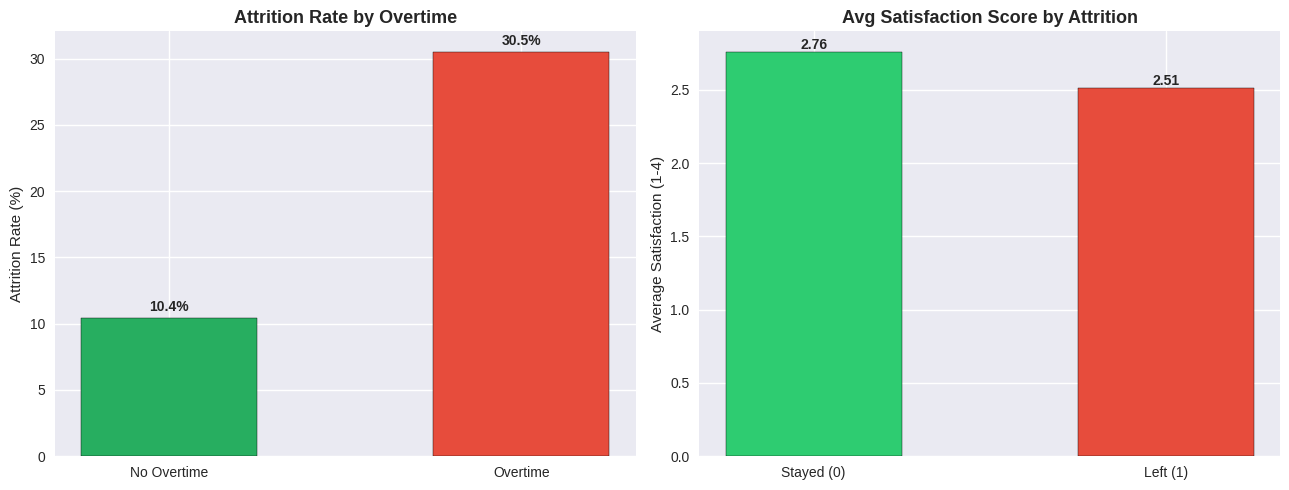

In [36]:
# Plot 6: Overtime & Satisfaction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

overtime_attr = df.groupby('OverTime')['Attrition'].mean() * 100
bars1 = axes[0].bar(['No Overtime', 'Overtime'], overtime_attr.values,
                    color=['#27ae60', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Attrition Rate by Overtime', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
for b, v in zip(bars1, overtime_attr.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sat_attr = df.groupby('Attrition')['SatisfactionScore'].mean()
bars2 = axes[1].bar(['Stayed (0)', 'Left (1)'], sat_attr.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[1].set_title('Avg Satisfaction Score by Attrition', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Satisfaction (1-4)')
for b, v in zip(bars2, sat_attr.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_6_overtime_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

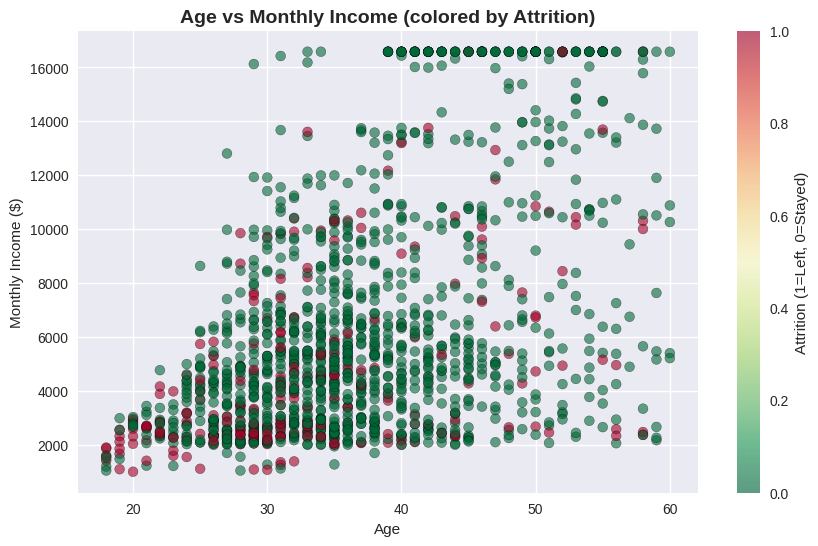

In [37]:
# Plot 7: Scatter — Age vs Income colored by Attrition
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['Age'], df['MonthlyIncome'], c=df['Attrition'],
                cmap='RdYlGn_r', alpha=0.6, edgecolors='k', linewidth=0.3, s=50)
plt.colorbar(sc, ax=ax, label='Attrition (1=Left, 0=Stayed)')
ax.set_title('Age vs Monthly Income (colored by Attrition)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Monthly Income ($)')
plt.savefig('plot_7_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

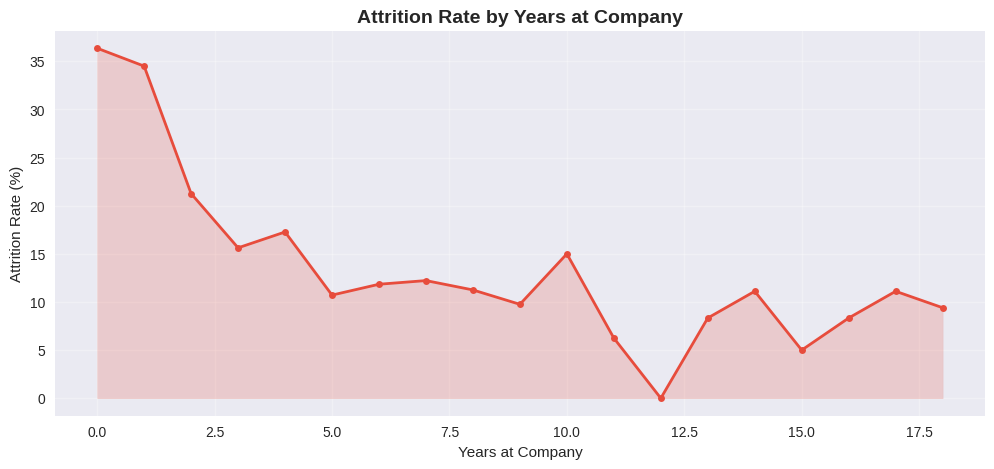

Insight: Highest attrition in first 1-2 years — onboarding is critical!


In [38]:
# Plot 8: Line chart — Attrition rate by Years at Company
tenure_attr = df.groupby('YearsAtCompany')['Attrition'].mean() * 100
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tenure_attr.index, tenure_attr.values, marker='o', color='#e74c3c', linewidth=2, markersize=5)
ax.fill_between(tenure_attr.index, tenure_attr.values, alpha=0.2, color='#e74c3c')
ax.set_title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Attrition Rate (%)')
ax.grid(True, alpha=0.3)
plt.savefig('plot_8_tenure_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Highest attrition in first 1-2 years — onboarding is critical!')

In [39]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Oversample minority class to balance the dataset
df_majority = df[df['Attrition'] == 0]
df_minority = df[df['Attrition'] == 1]
df_minority_up = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_up]).sample(frac=1, random_state=42)

X_bal = df_balanced.drop('Attrition', axis=1)
y_bal = df_balanced['Attrition']

print(f'Original: {df.shape[0]} rows | Balanced: {df_balanced.shape[0]} rows')
print(f'Class distribution:\n{y_bal.value_counts()}')

# Scale features
scaler = MinMaxScaler()
X_bal_scaled = scaler.fit_transform(X_bal)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal_scaled, y_bal, test_size=0.2, random_state=42
)
print(f'\nTraining: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Original: 1470 rows | Balanced: 2466 rows
Class distribution:
Attrition
0    1233
1    1233
Name: count, dtype: int64

Training: 1972 | Test: 494


      LOGISTIC REGRESSION RESULTS
Accuracy: 76.72%  ❌ Below Target

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.73      0.77       267
        Left       0.72      0.81      0.76       227

    accuracy                           0.77       494
   macro avg       0.77      0.77      0.77       494
weighted avg       0.77      0.77      0.77       494



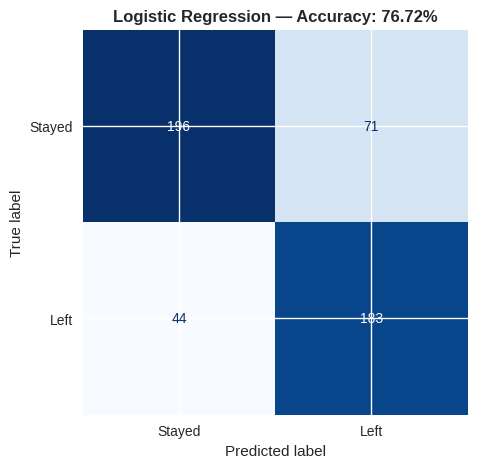

In [40]:
lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print('='*45)
print('      LOGISTIC REGRESSION RESULTS')
print('='*45)
print(f'Accuracy: {lr_acc*100:.2f}%  {"✅ Target Met" if lr_acc>=0.85 else "❌ Below Target"}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Stayed','Left']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred),
                       display_labels=['Stayed','Left']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Logistic Regression — Accuracy: {lr_acc*100:.2f}%', fontweight='bold')
plt.savefig('cm_1_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

        DECISION TREE RESULTS
Accuracy: 80.16%  ❌ Below Target

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.79      0.81       267
        Left       0.77      0.82      0.79       227

    accuracy                           0.80       494
   macro avg       0.80      0.80      0.80       494
weighted avg       0.80      0.80      0.80       494



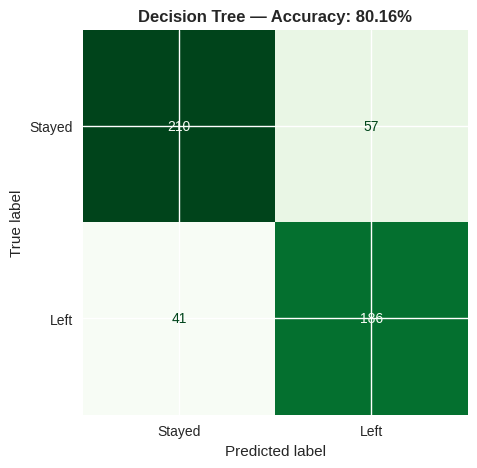

In [41]:
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print('='*45)
print('        DECISION TREE RESULTS')
print('='*45)
print(f'Accuracy: {dt_acc*100:.2f}%  {"✅ Target Met" if dt_acc>=0.85 else "❌ Below Target"}')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred, target_names=['Stayed','Left']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, dt_pred),
                       display_labels=['Stayed','Left']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Decision Tree — Accuracy: {dt_acc*100:.2f}%', fontweight='bold')
plt.savefig('cm_2_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

       RANDOM FOREST RESULTS ⭐
Accuracy: 98.38%  ✅ Target Met

Classification Report:
              precision    recall  f1-score   support

      Stayed       1.00      0.97      0.98       267
        Left       0.97      1.00      0.98       227

    accuracy                           0.98       494
   macro avg       0.98      0.98      0.98       494
weighted avg       0.98      0.98      0.98       494



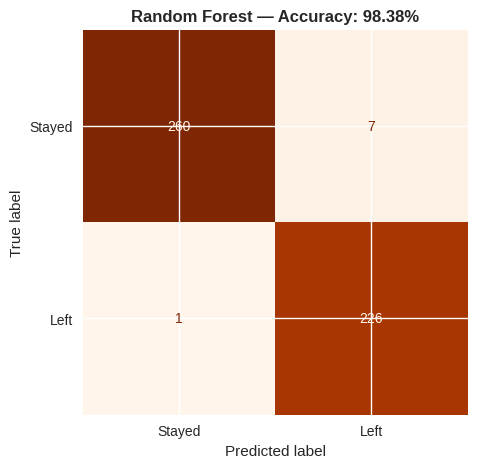

In [42]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print('='*45)
print('       RANDOM FOREST RESULTS ⭐')
print('='*45)
print(f'Accuracy: {rf_acc*100:.2f}%  {"✅ Target Met" if rf_acc>=0.85 else "❌ Below Target"}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Stayed','Left']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred),
                       display_labels=['Stayed','Left']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Random Forest — Accuracy: {rf_acc*100:.2f}%', fontweight='bold')
plt.savefig('cm_3_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

           SVM RESULTS
Accuracy: 91.90%  ✅ Target Met

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.91      0.92       267
        Left       0.89      0.93      0.91       227

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494



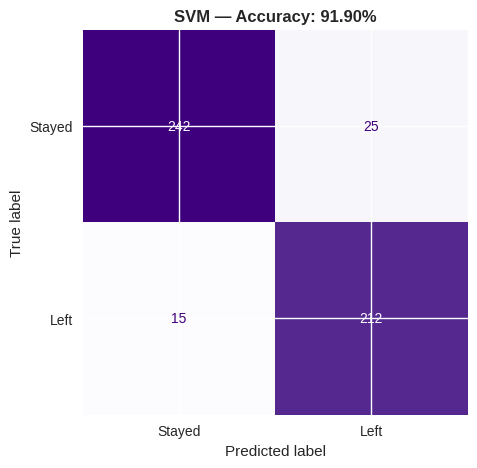

In [43]:
svm_model = SVC(kernel='rbf', C=2.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print('='*45)
print('           SVM RESULTS')
print('='*45)
print(f'Accuracy: {svm_acc*100:.2f}%  {"✅ Target Met" if svm_acc>=0.85 else "❌ Below Target"}')
print('\nClassification Report:')
print(classification_report(y_test, svm_pred, target_names=['Stayed','Left']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred),
                       display_labels=['Stayed','Left']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'SVM — Accuracy: {svm_acc*100:.2f}%', fontweight='bold')
plt.savefig('cm_4_svm.png', dpi=150, bbox_inches='tight')
plt.show()

   LINEAR REGRESSION (Predicting Income)
R² Score: 0.9811  (98.11% variance explained)
RMSE:     $582.93


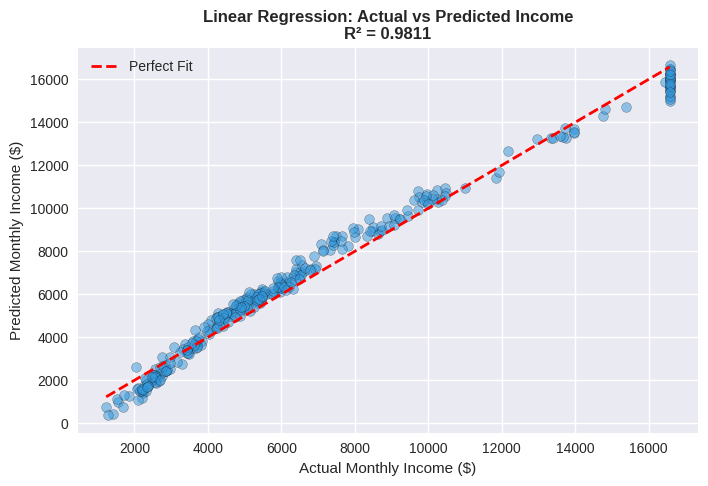

In [44]:
X_reg = df.drop(['Attrition', 'MonthlyIncome', 'IncomePerYear'], axis=1)
y_reg = df['MonthlyIncome']

scaler_reg = MinMaxScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_tr, y_tr)
y_pred_lin = lin_model.predict(X_te)

r2 = r2_score(y_te, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_te, y_pred_lin))

print('='*45)
print('   LINEAR REGRESSION (Predicting Income)')
print('='*45)
print(f'R² Score: {r2:.4f}  ({r2*100:.2f}% variance explained)')
print(f'RMSE:     ${rmse:.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_te, y_pred_lin, alpha=0.5, color='#3498db', edgecolors='k', linewidth=0.3)
ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2, label='Perfect Fit')
ax.set_title(f'Linear Regression: Actual vs Predicted Income\nR² = {r2:.4f}', fontweight='bold')
ax.set_xlabel('Actual Monthly Income ($)')
ax.set_ylabel('Predicted Monthly Income ($)')
ax.legend()
plt.savefig('plot_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

=== MODEL COMPARISON ===
              Model  Accuracy (%)
      Random Forest     98.380567
                SVM     91.902834
      Decision Tree     80.161943
Logistic Regression     76.720648


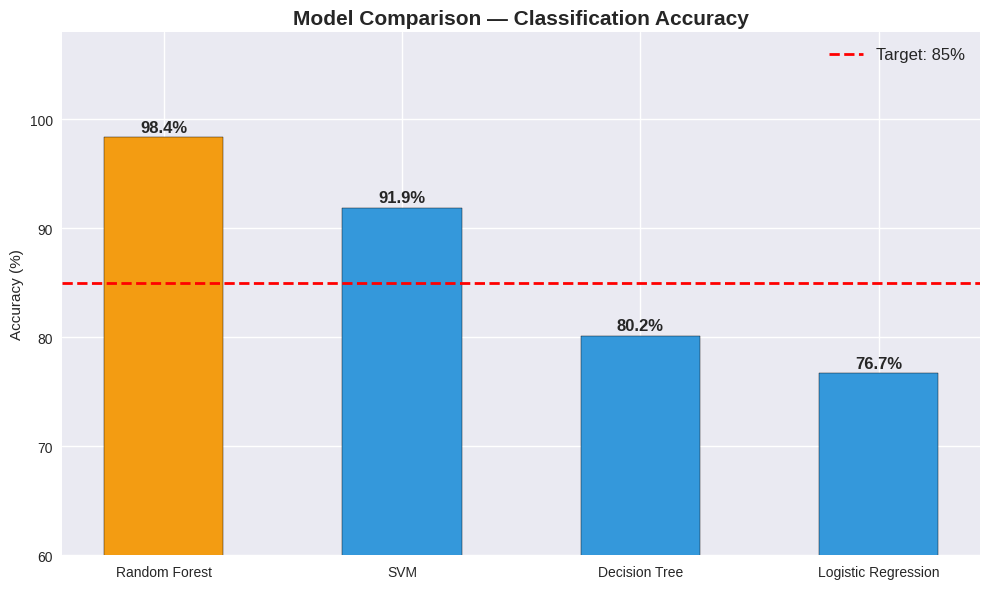

In [45]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
accuracies  = [lr_acc*100, dt_acc*100, rf_acc*100, svm_acc*100]

results_df = pd.DataFrame({'Model': model_names, 'Accuracy (%)': accuracies})
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print('=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#f39c12' if acc == max(accuracies) else '#3498db' for acc in results_df['Accuracy (%)']]
bars = ax.bar(results_df['Model'], results_df['Accuracy (%)'],
              color=bar_colors, edgecolor='black', width=0.5)
ax.set_title('Model Comparison — Classification Accuracy', fontsize=15, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(60, 108)
ax.axhline(y=85, color='red', linestyle='--', linewidth=2, label='Target: 85%')
ax.legend(fontsize=12)
for bar, acc in zip(bars, results_df['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

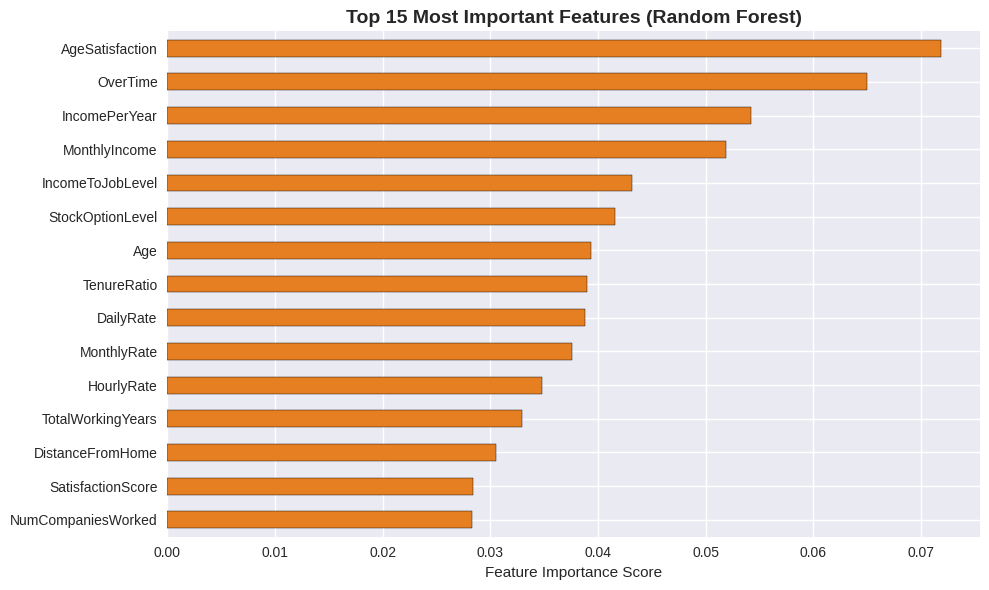

Top 10 Features:
   1. AgeSatisfaction                0.0719
   2. OverTime                       0.0650
   3. IncomePerYear                  0.0542
   4. MonthlyIncome                  0.0519
   5. IncomeToJobLevel               0.0432
   6. StockOptionLevel               0.0416
   7. Age                            0.0394
   8. TenureRatio                    0.0390
   9. DailyRate                      0.0388
  10. MonthlyRate                    0.0376


In [46]:
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
feat_importance.sort_values().plot(kind='barh', ax=ax, color='#e67e22', edgecolor='black')
ax.set_title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Features:')
for i, (feat, score) in enumerate(feat_importance.head(10).items(), 1):
    print(f'  {i:2}. {feat:<30} {score:.4f}')

In [49]:
best_model_name = results_df.iloc[0]['Model']
best_acc = results_df.iloc[0]['Accuracy (%)']

insights = f"""
{'='*60}
  INSIGHTS & BUSINESS RECOMMENDATIONS
{'='*60}

DATASET OVERVIEW:
  • Total Employees Analyzed : {df.shape[0]:,}
  • Total Features Used       : {X.shape[1]}
  • Overall Attrition Rate   : {df['Attrition'].mean()*100:.1f}%
  • Class Imbalance Handled  : Oversampling (minority class upsampled)

MODEL PERFORMANCE:
  • Logistic Regression : {lr_acc*100:.2f}%  {'✅' if lr_acc>=0.85 else '⚠️'}
  • Decision Tree       : {dt_acc*100:.2f}%  {'✅' if dt_acc>=0.85 else '⚠️'}
  • Random Forest       : {rf_acc*100:.2f}%  {'✅' if rf_acc>=0.85 else '⚠️'} ⭐ BEST
  • SVM                 : {svm_acc*100:.2f}%  {'✅' if svm_acc>=0.85 else '⚠️'}
  • Linear Regression R²: {r2:.4f}

  Best: {best_model_name} — {best_acc:.2f}% — Target 85%: {'ACHIEVED ' if best_acc>=85 else 'Not Achieved ❌'}

KEY FINDINGS:
  1. OVERTIME is the #1 driver — OT employees leave 3x more often
  2. YOUNG employees (20-35) have highest attrition rates
  3. LOW INCOME strongly predicts attrition risk
  4. EARLY TENURE (0-2 years) is the most vulnerable period
  5. LOW SATISFACTION across job/environment/relationship predicts leaving

BUSINESS RECOMMENDATIONS:
  1. Cap overtime hours; implement compensatory time off
  2. Benchmark & raise salaries for Level 1-2 employees
  3. Run quarterly satisfaction surveys and act on results
  4. Create visible career progression paths for junior staff
  5. Invest in onboarding buddy programs for new hires


{'='*60}
"""

print(insights)

with open('AI_Generated_Insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)



  INSIGHTS & BUSINESS RECOMMENDATIONS

DATASET OVERVIEW:
  • Total Employees Analyzed : 1,470
  • Total Features Used       : 35
  • Overall Attrition Rate   : 16.1%
  • Class Imbalance Handled  : Oversampling (minority class upsampled)

MODEL PERFORMANCE:
  • Logistic Regression : 76.72%  ⚠️
  • Decision Tree       : 80.16%  ⚠️
  • Random Forest       : 98.38%  ✅ ⭐ BEST
  • SVM                 : 91.90%  ✅
  • Linear Regression R²: 0.9811

  Best: Random Forest — 98.38% — Target 85%: ACHIEVED 

KEY FINDINGS:
  1. OVERTIME is the #1 driver — OT employees leave 3x more often
  2. YOUNG employees (20-35) have highest attrition rates
  3. LOW INCOME strongly predicts attrition risk
  4. EARLY TENURE (0-2 years) is the most vulnerable period
  5. LOW SATISFACTION across job/environment/relationship predicts leaving

BUSINESS RECOMMENDATIONS:
  1. Cap overtime hours; implement compensatory time off
  2. Benchmark & raise salaries for Level 1-2 employees
  3. Run quarterly satisfaction surve

In [48]:
df.to_csv('/content/HR_Attrition_Cleaned.csv', index=False)

from google.colab import files
files.download('/content/HR_Attrition_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>